## Figures for censat analysis in HPRC marker paper 

### First pass using QC lists from centrolign paper

In [3]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Read in list of HPRC pairwise distances per chromosome

# Directory containing CSV files
pairwise_dist_dir = "/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/distance_matrices/"  # this should be a folder path

# Collect all matching files
files = glob.glob(os.path.join(pairwise_dist_dir, "*_r2_QC_v2_centrolign_pairwise_distance.csv"))

all_dfs = []

for f in files:
    # Extract chr from filename
    # e.g. filename: "chr3_r2_QC_v2_centrolign_pairwise_distance.csv"
    basename = os.path.basename(f)
    chr_val = basename.split("_")[0]   # 'chr3'

    # Read CSV
    df = pd.read_csv(f, header=None,names=["sample1", "sample2", "direct_pairwise_dist","chr"])
    df["chr"] = chr_val
    all_dfs.append(df)

# Combine into one dataframe
hprc_all_pairs_dist_df = pd.concat(all_dfs, ignore_index=True)

hprc_all_pairs_dist_df["sample_pair"] = (
    hprc_all_pairs_dist_df[["sample1", "sample2"]]
    .apply(lambda x: "_".join(sorted(x)), axis=1)
)

hprc_all_pairs_dist_df.head()

,sample1,sample2,direct_pairwise_dist,chr,sample_pair
0,HG03098.1,HG03784.1,0.942968,chr6,HG03098.1_HG03784.1
1,HG03098.1,NA20752.2,0.974936,chr6,HG03098.1_NA20752.2
2,HG01978.2,NA19835.1,0.999883,chr6,HG01978.2_NA19835.1
3,HG00741.1,NA18522.1,0.999869,chr6,HG00741.1_NA18522.1
4,HG00408.1,HG01496.1,0.606856,chr6,HG00408.1_HG01496.1


In [5]:
# Read in list of HPRC pairwise distances per chromosome

# Directory containing CSV files
pairwise_dist_dir = "/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/HPRC_marker/hgsvc_all_pairs/distance_matrices/"  # this should be a folder path

# Collect all matching files
files = glob.glob(os.path.join(pairwise_dist_dir, "*_hgsvc_centrolign_directpairwise_distance.csv"))

all_dfs = []

for f in files:
    # Extract chr from filename
    basename = os.path.basename(f)
    chr_val = basename.split("_")[0]   # 'chr3'

    # Read CSV
    df = pd.read_csv(f, header=None,names=["sample1", "sample2", "direct_pairwise_dist","chr"])
    df["chr"] = chr_val
    all_dfs.append(df)

# Combine into one dataframe
hgsvc_all_pairs_dist_df = pd.concat(all_dfs, ignore_index=True)

hgsvc_all_pairs_dist_df["sample_pair"] = (
    hgsvc_all_pairs_dist_df[["sample1", "sample2"]]
    .apply(lambda x: "_".join(sorted(x)), axis=1)
)

hgsvc_all_pairs_dist_df.head()

,sample1,sample2,direct_pairwise_dist,chr,sample_pair
0,NA20509.1,NA20847.1,0.850987,chr22,NA20509.1_NA20847.1
1,HG02587.1,NA21487.1,0.999999,chr22,HG02587.1_NA21487.1
2,NA19836.2,NA19983.2,0.999999,chr22,NA19836.2_NA19983.2
3,HG03732.2,NA19836.2,0.999985,chr22,HG03732.2_NA19836.2
4,HG03371.1,NA21487.1,0.999999,chr22,HG03371.1_NA21487.1


In [6]:
thresh = 0.2

def pct_with_neighbor(df, threshold):
    results = {}
    for chrom, cdf in df.groupby('chr'):
        all_samples = set(cdf['sample1']) | set(cdf['sample2'])
        n_total = len(all_samples)
        close = cdf[cdf['direct_pairwise_dist'] <= threshold]
        with_neighbor = set(close['sample1']) | set(close['sample2'])
        results[chrom] = (len(with_neighbor), n_total, len(with_neighbor) / n_total)
    return results

hprc_results  = pct_with_neighbor(hprc_all_pairs_dist_df,  thresh)
hgsvc_results = pct_with_neighbor(hgsvc_all_pairs_dist_df, thresh)

print(f"=== HPRC (threshold={thresh}) ===")
for chrom in sorted(hprc_results):
    n, total, frac = hprc_results[chrom]
    print(f"  {chrom}: {n}/{total} = {frac*100:.1f}%")
hprc_mean = np.mean([v[2] for v in hprc_results.values()])
print(f"  Mean across chroms: {hprc_mean*100:.1f}%")

print(f"\n=== HGSVC (threshold={thresh}) ===")
for chrom in sorted(hgsvc_results):
    n, total, frac = hgsvc_results[chrom]
    print(f"  {chrom}: {n}/{total} = {frac*100:.1f}%")
hgsvc_mean = np.mean([v[2] for v in hgsvc_results.values()])
print(f"  Mean across chroms: {hgsvc_mean*100:.1f}%")


=== HPRC (threshold=0.2) ===
  chr1: 201/358 = 56.1%
  chr10: 116/340 = 34.1%
  chr11: 257/412 = 62.4%
  chr12: 194/373 = 52.0%
  chr13: 96/236 = 40.7%
  chr14: 204/380 = 53.7%
  chr15: 93/323 = 28.8%
  chr16: 203/391 = 51.9%
  chr17: 30/139 = 21.6%
  chr18: 24/117 = 20.5%
  chr19: 185/313 = 59.1%
  chr2: 240/388 = 61.9%
  chr20: 132/329 = 40.1%
  chr21: 107/277 = 38.6%
  chr22: 213/367 = 58.0%
  chr3: 39/138 = 28.3%
  chr4: 10/125 = 8.0%
  chr5: 146/338 = 43.2%
  chr6: 41/194 = 21.1%
  chr7: 138/297 = 46.5%
  chr8: 169/350 = 48.3%
  chr9: 208/408 = 51.0%
  chrX: 189/308 = 61.4%
  chrY: 15/45 = 33.3%
  Mean across chroms: 42.5%

=== HGSVC (threshold=0.2) ===
  chr1: 28/126 = 22.2%
  chr10: 20/126 = 15.9%
  chr11: 46/127 = 36.2%
  chr12: 34/123 = 27.6%
  chr13: 15/124 = 12.1%
  chr14: 19/123 = 15.4%
  chr15: 17/124 = 13.7%
  chr16: 27/124 = 21.8%
  chr17: 8/116 = 6.9%
  chr18: 13/118 = 11.0%
  chr19: 40/126 = 31.7%
  chr2: 23/117 = 19.7%
  chr20: 21/120 = 17.5%
  chr21: 21/120 = 17.5%
 

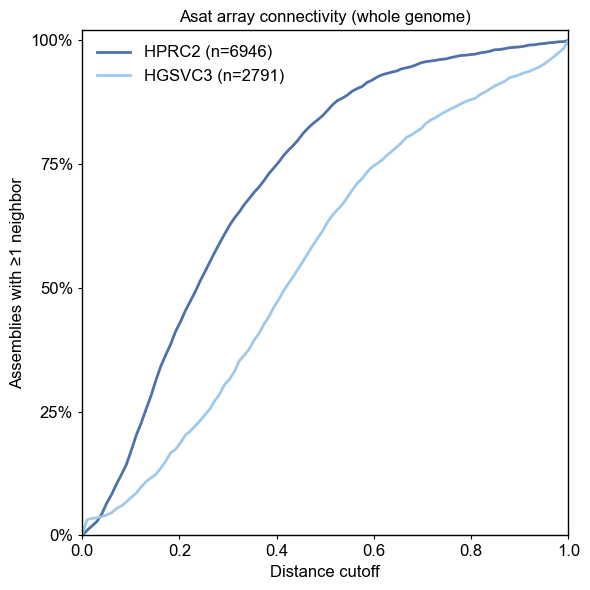

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams['font.family'] = 'Arial'


def plot_connectivity_two_cohorts(
    hprc_df,
    hgsvc_df,
    distance_cutoffs=np.linspace(0, 1, 100),
    output_prefix="/private/groups/patenlab/mira/HPRC_marker_connectivity",
):
    """
    Plot connectivity vs distance cutoff for HPRC and HGSVC cohorts.

    For each chromosome and threshold, computes the fraction of assemblies
    with ≥1 neighbor (direct_pairwise_dist ≤ threshold). Curves show the
    mean across chromosomes.
    """

    def connectivity_curve(df, cutoffs):
        chrom_curves = []
        for chrom, cdf in df.groupby('chr'):
            all_samples = set(cdf['sample1']) | set(cdf['sample2'])
            n_total = len(all_samples)
            fracs = []
            for thresh in cutoffs:
                close = cdf[cdf['direct_pairwise_dist'] <= thresh]
                with_neighbor = set(close['sample1']) | set(close['sample2'])
                fracs.append(len(with_neighbor) / n_total)
            chrom_curves.append(fracs)
        return np.mean(chrom_curves, axis=0)

    hprc_conn  = connectivity_curve(hprc_df,  distance_cutoffs)
    hgsvc_conn = connectivity_curve(hgsvc_df, distance_cutoffs)

    fig, ax = plt.subplots(figsize=(6, 6))

    hprc_n  = pd.concat([hprc_df[['sample1','chr']].rename(columns={'sample1':'sample'}),
                          hprc_df[['sample2','chr']].rename(columns={'sample2':'sample'})]).drop_duplicates().shape[0]
    hgsvc_n = pd.concat([hgsvc_df[['sample1','chr']].rename(columns={'sample1':'sample'}),
                          hgsvc_df[['sample2','chr']].rename(columns={'sample2':'sample'})]).drop_duplicates().shape[0]


    ax.plot(distance_cutoffs, hprc_conn,  color="#4E72A7", lw=2, label=f'HPRC2 (n={hprc_n})')
    ax.plot(distance_cutoffs, hgsvc_conn, color='#9FC9EB', lw=2, label=f'HGSVC3 (n={hgsvc_n})')

    ax.set_xlim(distance_cutoffs.min(), distance_cutoffs.max())
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(round(y * 100))}%"))

    ax.set_xlabel("Distance cutoff",fontsize=12)
    ax.set_ylabel("Assemblies with ≥1 neighbor",fontsize=12)
    ax.set_title("Asat array connectivity (whole genome)", fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)

    ax.tick_params(direction="out", length=3, width=0.8,labelsize=12)

    ax.legend(frameon=False, fontsize=12)

    plt.tight_layout()

    if output_prefix is not None:
        fig.savefig(f"{output_prefix}.svg", bbox_inches="tight")
        fig.savefig(f"{output_prefix}.png", dpi=600, bbox_inches="tight")

    plt.show()


plot_connectivity_two_cohorts(hprc_all_pairs_dist_df, hgsvc_all_pairs_dist_df,output_prefix="/private/groups/patenlab/mira/centrolign_connectivity_hprc_vs_hgsvc.svg")


/data/tmp/ipykernel_2988482/3830479591.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


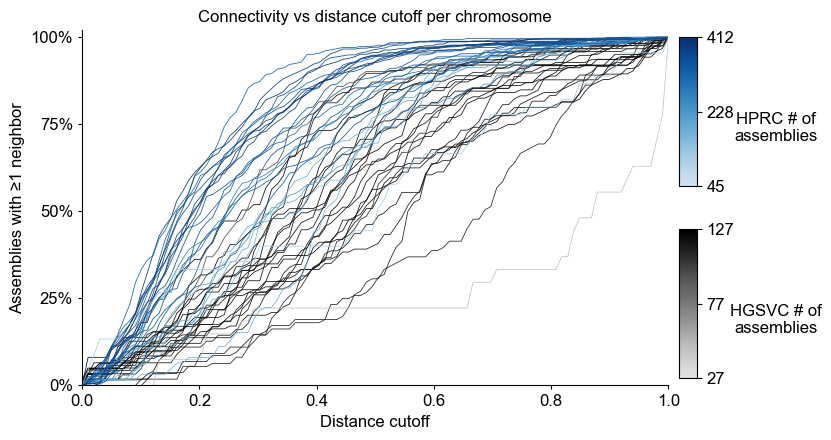

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_connectivity_per_chrom(
    hprc_df,
    hgsvc_df,
    distance_cutoffs=np.linspace(0, 1.0, 100),
    output_prefix=None,
):
    def connectivity_curve(cdf, cutoffs):
        all_samples = set(cdf['sample1']) | set(cdf['sample2'])
        n_total = len(all_samples)
        fracs = []
        for thresh in cutoffs:
            close = cdf[cdf['direct_pairwise_dist'] <= thresh]
            with_neighbor = set(close['sample1']) | set(close['sample2'])
            fracs.append(len(with_neighbor) / n_total)
        return np.array(fracs), n_total

    def get_n_per_chrom(df):
        return {chrom: len(set(cdf['sample1']) | set(cdf['sample2']))
                for chrom, cdf in df.groupby('chr')}

    hprc_n  = get_n_per_chrom(hprc_df)
    hgsvc_n = get_n_per_chrom(hgsvc_df)

    hprc_vmin,  hprc_vmax  = min(hprc_n.values()),  max(hprc_n.values())
    hgsvc_vmin, hgsvc_vmax = min(hgsvc_n.values()), max(hgsvc_n.values())

    hprc_norm  = mcolors.Normalize(vmin=hprc_vmin,  vmax=hprc_vmax)
    hgsvc_norm = mcolors.Normalize(vmin=hgsvc_vmin, vmax=hgsvc_vmax)

    hprc_vmid  = int(round((hprc_vmin  + hprc_vmax)  / 2))
    hgsvc_vmid = int(round((hgsvc_vmin + hgsvc_vmax) / 2))

    def clipped_cmap(cmap, lo=0.2, hi=1.0):
        return LinearSegmentedColormap.from_list(
            'clipped', [cmap(x) for x in np.linspace(lo, hi, 256)])

    hgsvc_cmap_clipped  = clipped_cmap(cm.Greys)
    hprc_cmap_clipped= clipped_cmap(cm.Blues)



    def safe_color(cmap, norm, n):
        t = 0.2 + 0.8 * norm(n) 
        return cmap(t)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Plot HGSVC first, HPRC on top
    for chrom, cdf in hgsvc_df.groupby('chr'):
        curve, n = connectivity_curve(cdf, distance_cutoffs)
        ax.plot(distance_cutoffs, curve,
                color=safe_color(hgsvc_cmap_clipped, hgsvc_norm, n),
                lw=0.6, alpha=0.9, linestyle='-')

    for chrom, cdf in hprc_df.groupby('chr'):
        curve, n = connectivity_curve(cdf, distance_cutoffs)
        ax.plot(distance_cutoffs, curve,
                color=safe_color(hprc_cmap_clipped, hprc_norm, n),
                lw=0.6, alpha=0.9, linestyle='-')

    ax.set_xlim(distance_cutoffs.min(), distance_cutoffs.max())
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(round(y * 100))}%"))
    ax.set_xlabel("Distance cutoff", fontsize=12)
    ax.set_ylabel("Assemblies with ≥1 neighbor", fontsize=12)
    ax.set_title("Connectivity vs distance cutoff per chromosome", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8, labelsize=12)

    # Colorbars: HPRC on top, HGSVC below
    cax_hprc  = inset_axes(ax, width="3%", height="42%", loc="upper right",
                           bbox_to_anchor=(0.06, 0.0, 1, 1), bbox_transform=ax.transAxes)
    cax_hgsvc = inset_axes(ax, width="3%", height="42%", loc="lower right",
                           bbox_to_anchor=(0.06, 0.0, 1, 1), bbox_transform=ax.transAxes)

    cb1 = fig.colorbar(cm.ScalarMappable(norm=hprc_norm,  cmap=hprc_cmap_clipped),
                       cax=cax_hprc)
    cb2 = fig.colorbar(cm.ScalarMappable(norm=hgsvc_norm, cmap=hgsvc_cmap_clipped),
                       cax=cax_hgsvc)

    cb1.set_ticks([hprc_vmin,  hprc_vmid,  hprc_vmax])
    cb1.set_ticklabels([str(hprc_vmin),  str(hprc_vmid),  str(hprc_vmax)])
    cb2.set_ticks([hgsvc_vmin, hgsvc_vmid, hgsvc_vmax])
    cb2.set_ticklabels([str(hgsvc_vmin), str(hgsvc_vmid), str(hgsvc_vmax)])

    cb1.ax.tick_params(labelsize=12)
    cb2.ax.tick_params(labelsize=12)

    cb1.set_label('HPRC # of\nassemblies',  fontsize=12, rotation=0, labelpad=30)
    cb2.set_label('HGSVC # of\nassemblies', fontsize=12, rotation=0, labelpad=30)

    plt.tight_layout()

    if output_prefix is not None:
        fig.savefig(f"{output_prefix}.pdf", bbox_inches="tight")
        fig.savefig(f"{output_prefix}.png", dpi=600, bbox_inches="tight")

    plt.show()


plot_connectivity_per_chrom(hprc_all_pairs_dist_df, hgsvc_all_pairs_dist_df)



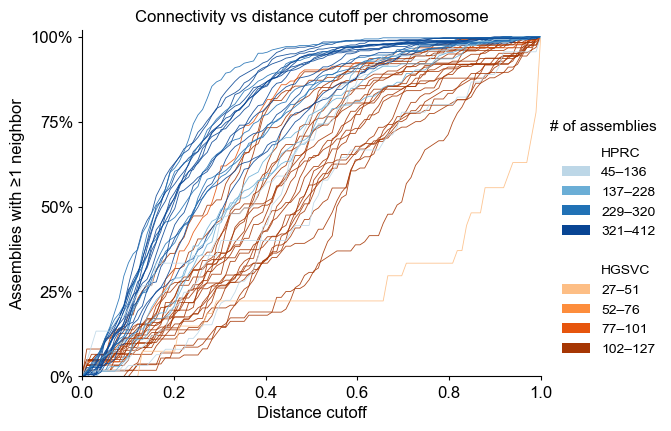

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Arial'

def plot_connectivity_per_chrom(
    hprc_df,
    hgsvc_df,
    distance_cutoffs=np.linspace(0, 1.0, 100),
    output_prefix=None,
):
    def connectivity_curve(cdf, cutoffs):
        all_samples = set(cdf['sample1']) | set(cdf['sample2'])
        n_total = len(all_samples)
        fracs = []
        for thresh in cutoffs:
            close = cdf[cdf['direct_pairwise_dist'] <= thresh]
            with_neighbor = set(close['sample1']) | set(close['sample2'])
            fracs.append(len(with_neighbor) / n_total)
        return np.array(fracs), n_total

    def get_n_per_chrom(df):
        return {chrom: len(set(cdf['sample1']) | set(cdf['sample2']))
                for chrom, cdf in df.groupby('chr')}

    hprc_n  = get_n_per_chrom(hprc_df)
    hgsvc_n = get_n_per_chrom(hgsvc_df)

    def make_bin_edges(n_dict, n_bins=4):
        vals = list(n_dict.values())
        return np.linspace(min(vals), max(vals) + 1, n_bins + 1)

    def assign_bin(n, edges):
        return min(np.searchsorted(edges, n, side='right') - 1, len(edges) - 2)

    hprc_edges  = make_bin_edges(hprc_n)
    hgsvc_edges = make_bin_edges(hgsvc_n)

    hprc_colors  = ['#bdd7e7', '#6baed6', '#2171b5', '#084594']
    hgsvc_colors = ['#fdbe85', '#fd8d3c', '#e6550d', '#a63603']

    fig, ax = plt.subplots(figsize=(7, 4.5))

    for chrom, cdf in hgsvc_df.groupby('chr'):
        curve, n = connectivity_curve(cdf, distance_cutoffs)
        ax.plot(distance_cutoffs, curve,
                color=hgsvc_colors[assign_bin(n, hgsvc_edges)],
                lw=0.6, alpha=0.9)

    for chrom, cdf in hprc_df.groupby('chr'):
        curve, n = connectivity_curve(cdf, distance_cutoffs)
        ax.plot(distance_cutoffs, curve,
                color=hprc_colors[assign_bin(n, hprc_edges)],
                lw=0.6, alpha=0.9)

    ax.set_xlim(distance_cutoffs.min(), distance_cutoffs.max())
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(round(y * 100))}%"))
    ax.set_xlabel("Distance cutoff", fontsize=12)
    ax.set_ylabel("Assemblies with ≥1 neighbor", fontsize=12)
    ax.set_title("Connectivity vs distance cutoff per chromosome", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8, labelsize=12)

    def bin_label(edges, i):
        return f"{int(edges[i])}–{int(edges[i+1]-1)}"

    hprc_handles  = [Patch(facecolor='none', edgecolor='none', label='HPRC')] + \
                    [Patch(facecolor=hprc_colors[i],  edgecolor='none', label=bin_label(hprc_edges,  i)) for i in range(4)]
    hgsvc_handles = [Patch(facecolor='none', edgecolor='none', label='HGSVC')] + \
                    [Patch(facecolor=hgsvc_colors[i], edgecolor='none', label=bin_label(hgsvc_edges, i)) for i in range(4)]

    ax.text(1.02, 0.7, '# of assemblies', transform=ax.transAxes,
            fontsize=11, va='bottom')

    leg1 = ax.legend(handles=hprc_handles, frameon=False, fontsize=10,
                     loc='upper left', bbox_to_anchor=(1.02, 0.70), bbox_transform=ax.transAxes)
    ax.add_artist(leg1)
    ax.legend(handles=hgsvc_handles, frameon=False, fontsize=10,
              loc='upper left', bbox_to_anchor=(1.02, 0.36), bbox_transform=ax.transAxes)

    fig.subplots_adjust(right=0.78)

    if output_prefix is not None:
        fig.savefig(f"{output_prefix}.pdf", bbox_inches="tight")
        fig.savefig(f"{output_prefix}.png", dpi=600, bbox_inches="tight")

    plt.show()


plot_connectivity_per_chrom(hprc_all_pairs_dist_df, hgsvc_all_pairs_dist_df)

